**LSA9 Phase Pattern Extractor - Morning**

In [1]:
from pathlib import Path
import json
import pandas as pd

# ============================================================
# CODE 5: LSA9 PHASE PATTERN EXTRACTOR
# ============================================================

SIGNAL_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\signal_states\LD-LSA9_e31ef6a7-ced8-42fe-9ac2-fef01677d7de"
)

OUT_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA9_saturation"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

SCENARIO_NAME = "weekday_morning"
TARGET_DATE = "2026-03-10"
WINDOW_START = "08:00:00"
WINDOW_END = "09:00:00"

OUT_CSV = OUT_DIR / f"LSA9_phase_blocks_{SCENARIO_NAME}.csv"
OUT_XLSX = OUT_DIR / f"LSA9_phase_blocks_{SCENARIO_NAME}.xlsx"

SIGNAL_GROUPS = {
    "K1": 1,
    "K2": 2,
    "K3": 3,
    "K4": 4,
}

GROUP_COLUMNS = ["K1", "K2", "K3", "K4"]

rows = []

for json_path in sorted(SIGNAL_DIR.glob("*.json")):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    start_utc = pd.to_datetime(data["start"])

    for value in data.get("values", []):
        timestamp_utc = start_utc + pd.to_timedelta(value.get("offset", 0), unit="ms")
        timestamp_local = timestamp_utc.tz_convert("Europe/Berlin")

        if str(timestamp_local.date()) != TARGET_DATE:
            continue

        start_t = pd.to_datetime(WINDOW_START).time()
        end_t = pd.to_datetime(WINDOW_END).time()

        if not (start_t <= timestamp_local.time() < end_t):
            continue

        sig_states = {item["id"]: item["sgState"] for item in value.get("sigState", [])}
        node_info = value.get("nodes", [{}])[0]

        row = {
            "timestamp_local": timestamp_local,
            "date": str(timestamp_local.date()),
            "time": timestamp_local.time(),
            "program": node_info.get("program"),
            "stage": node_info.get("stage"),
            "cycCnt": node_info.get("cycCnt"),
            "stgCnt": node_info.get("stgCnt"),
            "stgTran": node_info.get("stgTran"),
        }

        for group_name, signal_id in SIGNAL_GROUPS.items():
            row[group_name] = sig_states.get(signal_id)

        rows.append(row)

df = pd.DataFrame(rows)

if df.empty:
    raise ValueError("No signal data found for selected date and time window.")

df = df.sort_values("timestamp_local").reset_index(drop=True)

for col in GROUP_COLUMNS:
    if df[col].isna().any():
        raise ValueError(f"{col} has missing values. Check signal mapping.")
    df[col] = df[col].astype(int)

df["pattern"] = df[GROUP_COLUMNS].astype(str).agg("-".join, axis=1)
df["block_id"] = (df["pattern"] != df["pattern"].shift()).cumsum()

phase_blocks = (
    df.groupby("block_id")
    .agg(
        start_time=("timestamp_local", "first"),
        end_time=("timestamp_local", "last"),
        date=("date", "first"),
        K1=("K1", "first"),
        K2=("K2", "first"),
        K3=("K3", "first"),
        K4=("K4", "first"),
        pattern=("pattern", "first"),
        stage=("stage", "first"),
        program=("program", "first"),
        n_seconds=("pattern", "count"),
    )
    .reset_index()
)

phase_blocks["duration_s"] = phase_blocks["n_seconds"]

pattern_summary = (
    phase_blocks
    .groupby(["pattern"] + GROUP_COLUMNS)
    .agg(
        occurrences=("block_id", "count"),
        total_duration_s=("duration_s", "sum"),
        mean_duration_s=("duration_s", "mean"),
        median_duration_s=("duration_s", "median"),
        min_duration_s=("duration_s", "min"),
        max_duration_s=("duration_s", "max"),
    )
    .reset_index()
    .sort_values("total_duration_s", ascending=False)
)

phase_blocks_excel = phase_blocks.copy()
phase_blocks_excel["start_time"] = phase_blocks_excel["start_time"].astype(str)
phase_blocks_excel["end_time"] = phase_blocks_excel["end_time"].astype(str)

df_excel = df.copy()
df_excel["timestamp_local"] = df_excel["timestamp_local"].astype(str)

phase_blocks_excel.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")

with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as writer:
    phase_blocks_excel.to_excel(writer, sheet_name="Phase_Blocks", index=False)
    pattern_summary.to_excel(writer, sheet_name="Pattern_Summary", index=False)
    df_excel.to_excel(writer, sheet_name="Secondwise_K1_K4", index=False)

print("Saved CSV:")
print(OUT_CSV)

print("\nSaved Excel:")
print(OUT_XLSX)

print("\nTop recurring patterns:")
print(pattern_summary.head(20))

Saved CSV:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA9_saturation\LSA9_phase_blocks_weekday_morning.csv

Saved Excel:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA9_saturation\LSA9_phase_blocks_weekday_morning.xlsx

Top recurring patterns:
    pattern  K1  K2  K3  K4  occurrences  total_duration_s  mean_duration_s  \
13  4-2-4-2   4   2   4   2           39              1251        32.076923   
0   2-2-2-2   2   2   2   2          108               521         4.824074   
11  4-2-2-2   4   2   2   2           30               491        16.366667   
7   2-4-2-2   2   4   2   2           37               440        11.891892   
2   2-2-2-4   2   2   2   4           32               342        10.687500   
6   2-3-2-2   2   3   2   2           36               108         3.000000   
1   2-2-2-3   2   2   2   3           32                96         3.000000   
9   3-2-2-2   3   2   2   2           31                91         2.935484   
12  4-2-3-2   

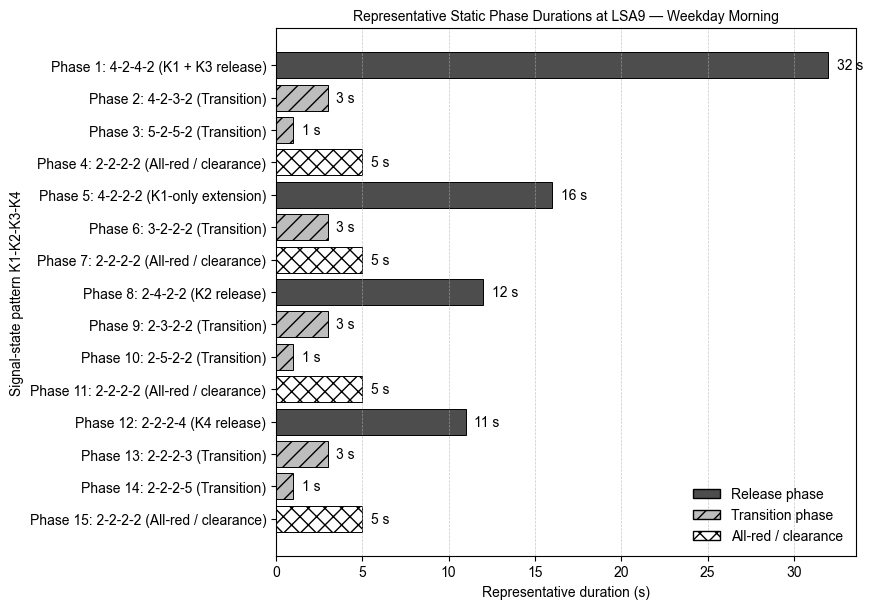

Saved:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA9_saturation\figures\LSA9_representative_phase_durations_weekday_morning_accessible.png
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA9_saturation\figures\LSA9_representative_phase_durations_weekday_morning_accessible.svg

Representative static phase table:
    phase  pattern  phase_type          description  representative_duration_s
0       1  4-2-4-2     Release      K1 + K3 release                         32
1       2  4-2-3-2  Transition           Transition                          3
2       3  5-2-5-2  Transition           Transition                          1
3       4  2-2-2-2   Clearance  All-red / clearance                          5
4       5  4-2-2-2     Release    K1-only extension                         16
5       6  3-2-2-2  Transition           Transition                          3
6       7  2-2-2-2   Clearance  All-red / clearance                          5
7       8  2-4-2-2     Rele

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CODE 5B: LSA9 REPRESENTATIVE PHASE DURATION FIGURE
# ============================================================
# Purpose:
# - Read LSA9 phase block output
# - Create a thesis-style horizontal bar chart
# - Use representative recurring phase patterns from Pattern_Summary
# - Distinguish release, transition, and clearance phases
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

# ============================================================
# SETTINGS
# ============================================================

BASE_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA9_saturation"
)

IN_XLSX = BASE_DIR / "LSA9_phase_blocks_weekday_morning.xlsx"

OUT_DIR = BASE_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PNG = OUT_DIR / "LSA9_representative_phase_durations_weekday_morning_accessible.png"
OUT_SVG = OUT_DIR / "LSA9_representative_phase_durations_weekday_morning_accessible.svg"

# ============================================================
# LOAD DATA
# ============================================================

pattern_summary = pd.read_excel(IN_XLSX, sheet_name="Pattern_Summary")

duration_lookup = {
    row["pattern"]: int(round(row["mean_duration_s"]))
    for _, row in pattern_summary.iterrows()
}

# ============================================================
# REPRESENTATIVE PHASE SEQUENCE FOR LSA9
# ============================================================
# Pattern order: K1-K2-K3-K4
#
# Main observed release patterns:
# 4-2-4-2 = K1 + K3 release
# 4-2-2-2 = K1-only extension
# 2-4-2-2 = K2 release
# 2-2-2-4 = K4 release
# ============================================================

representative_rows = [
    {
        "phase": 1,
        "pattern": "4-2-4-2",
        "phase_type": "Release",
        "description": "K1 + K3 release"
    },
    {
        "phase": 2,
        "pattern": "4-2-3-2",
        "phase_type": "Transition",
        "description": "Transition"
    },
    {
        "phase": 3,
        "pattern": "5-2-5-2",
        "phase_type": "Transition",
        "description": "Transition"
    },
    {
        "phase": 4,
        "pattern": "2-2-2-2",
        "phase_type": "Clearance",
        "description": "All-red / clearance"
    },
    {
        "phase": 5,
        "pattern": "4-2-2-2",
        "phase_type": "Release",
        "description": "K1-only extension"
    },
    {
        "phase": 6,
        "pattern": "3-2-2-2",
        "phase_type": "Transition",
        "description": "Transition"
    },
    {
        "phase": 7,
        "pattern": "2-2-2-2",
        "phase_type": "Clearance",
        "description": "All-red / clearance"
    },
    {
        "phase": 8,
        "pattern": "2-4-2-2",
        "phase_type": "Release",
        "description": "K2 release"
    },
    {
        "phase": 9,
        "pattern": "2-3-2-2",
        "phase_type": "Transition",
        "description": "Transition"
    },
    {
        "phase": 10,
        "pattern": "2-5-2-2",
        "phase_type": "Transition",
        "description": "Transition"
    },
    {
        "phase": 11,
        "pattern": "2-2-2-2",
        "phase_type": "Clearance",
        "description": "All-red / clearance"
    },
    {
        "phase": 12,
        "pattern": "2-2-2-4",
        "phase_type": "Release",
        "description": "K4 release"
    },
    {
        "phase": 13,
        "pattern": "2-2-2-3",
        "phase_type": "Transition",
        "description": "Transition"
    },
    {
        "phase": 14,
        "pattern": "2-2-2-5",
        "phase_type": "Transition",
        "description": "Transition"
    },
    {
        "phase": 15,
        "pattern": "2-2-2-2",
        "phase_type": "Clearance",
        "description": "All-red / clearance"
    },
]

df = pd.DataFrame(representative_rows)
df["representative_duration_s"] = df["pattern"].map(duration_lookup)

missing = df[df["representative_duration_s"].isna()]
if not missing.empty:
    raise ValueError(
        "Some representative patterns were not found in Pattern_Summary:\n"
        + str(missing[["phase", "pattern", "description"]])
    )

df["representative_duration_s"] = df["representative_duration_s"].astype(int)

# ============================================================
# ACCESSIBLE STYLE
# ============================================================

STYLE = {
    "Release": {
        "color": "#4D4D4D",
        "hatch": "",
        "label": "Release phase"
    },
    "Transition": {
        "color": "#BDBDBD",
        "hatch": "//",
        "label": "Transition phase"
    },
    "Clearance": {
        "color": "#FFFFFF",
        "hatch": "xx",
        "label": "All-red / clearance"
    },
}

# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(8.8, 6.2))

y_labels = [
    f"Phase {row.phase}: {row.pattern} ({row.description})"
    for _, row in df.iterrows()
]

for i, row in df.iterrows():
    style = STYLE[row["phase_type"]]

    ax.barh(
        y_labels[i],
        row["representative_duration_s"],
        color=style["color"],
        edgecolor="black",
        linewidth=0.7,
        hatch=style["hatch"]
    )

ax.set_title("Representative Static Phase Durations at LSA9 — Weekday Morning")
ax.set_xlabel("Representative duration (s)")
ax.set_ylabel("Signal-state pattern K1-K2-K3-K4")
ax.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.7)

for i, row in df.iterrows():
    ax.text(
        row["representative_duration_s"] + 0.5,
        i,
        f"{row['representative_duration_s']} s",
        va="center"
    )

ax.invert_yaxis()

legend_handles = []
legend_labels = []

for phase_type, style in STYLE.items():
    handle = plt.Rectangle(
        (0, 0),
        1,
        1,
        facecolor=style["color"],
        edgecolor="black",
        hatch=style["hatch"]
    )
    legend_handles.append(handle)
    legend_labels.append(style["label"])

ax.legend(
    legend_handles,
    legend_labels,
    frameon=False,
    loc="lower right"
)

plt.tight_layout()

plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
plt.savefig(OUT_SVG, bbox_inches="tight")
plt.show()

print("Saved:")
print(OUT_PNG)
print(OUT_SVG)

print("\nRepresentative static phase table:")
print(df[[
    "phase",
    "pattern",
    "phase_type",
    "description",
    "representative_duration_s"
]])

print("\nApproximate representative cycle length:")
print(df["representative_duration_s"].sum(), "seconds")

In [3]:
from pathlib import Path
import pandas as pd
from xml.dom import minidom
import xml.etree.ElementTree as ET

# ============================================================
# CODE 6: LSA9 STATIC SUMO TLS PROGRAM GENERATOR
# ============================================================

BASE_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA9_saturation"
)

IN_XLSX = BASE_DIR / "LSA9_phase_blocks_weekday_morning.xlsx"

OUT_XML = BASE_DIR / "LSA9_static_tls_weekday_morning.add.xml"
OUT_PHASE_TABLE_CSV = BASE_DIR / "LSA9_static_tls_weekday_morning_phase_table.csv"

TLS_ID = "tls_9873"
PROGRAM_ID = "derived_weekday_morning"

LINK_INDEX_TO_GROUP = {
    0: "K2",
    1: "K2",
    2: "K2",
    3: "K2",
    4: "K2",
    5: "K3",
    6: "K3",
    7: "K3",
    8: "K3",
    9: "K4",
    10: "K4",
    11: "K4",
    12: "K4",
    13: "K1",
    14: "K1",
    15: "K1",
    16: "K1",
    17: "K1",
    18: "K2",
    19: "K2",
    20: "K2",
    21: "K2",
}

def sgstate_to_sumo_char(sg_state):
    if sg_state == 4:
        return "G"
    elif sg_state in [3, 5]:
        return "y"
    elif sg_state == 2:
        return "r"
    else:
        return "r"

def pattern_to_sumo_state(pattern):
    k1, k2, k3, k4 = [int(x) for x in pattern.split("-")]

    group_state = {
        "K1": sgstate_to_sumo_char(k1),
        "K2": sgstate_to_sumo_char(k2),
        "K3": sgstate_to_sumo_char(k3),
        "K4": sgstate_to_sumo_char(k4),
    }

    return "".join(
        group_state[LINK_INDEX_TO_GROUP[idx]]
        for idx in sorted(LINK_INDEX_TO_GROUP.keys())
    )

phase_blocks = pd.read_excel(IN_XLSX, sheet_name="Phase_Blocks")

# First 20 compressed phase blocks as initial static approximation.
# After checking output, this can be simplified like LSA8/LSA10.
phase_table = phase_blocks.head(20).copy()

phase_table["phase"] = range(1, len(phase_table) + 1)
phase_table["sumo_state"] = phase_table["pattern"].apply(pattern_to_sumo_state)

phase_table = phase_table[[
    "phase",
    "pattern",
    "K1",
    "K2",
    "K3",
    "K4",
    "duration_s",
    "sumo_state",
]]

additional = ET.Element("additional")

tl_logic = ET.SubElement(
    additional,
    "tlLogic",
    {
        "id": TLS_ID,
        "type": "static",
        "programID": PROGRAM_ID,
        "offset": "0",
    }
)

for _, row in phase_table.iterrows():
    ET.SubElement(
        tl_logic,
        "phase",
        {
            "duration": str(int(row["duration_s"])),
            "state": row["sumo_state"],
        }
    )

rough_string = ET.tostring(additional, encoding="utf-8")
parsed = minidom.parseString(rough_string)
pretty_xml = parsed.toprettyxml(indent="    ")

with open(OUT_XML, "w", encoding="utf-8") as f:
    f.write(pretty_xml)

phase_table.to_csv(OUT_PHASE_TABLE_CSV, index=False, encoding="utf-8-sig")

print("Saved SUMO TLS additional file:")
print(OUT_XML)

print("\nSaved phase table:")
print(OUT_PHASE_TABLE_CSV)

print("\nGenerated static phase table:")
print(phase_table)

print("\nSUMO state string length:")
print(len(phase_table.iloc[0]["sumo_state"]))

print("\nApproximate static cycle length:")
print(phase_table["duration_s"].sum(), "seconds")

Saved SUMO TLS additional file:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA9_saturation\LSA9_static_tls_weekday_morning.add.xml

Saved phase table:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA9_saturation\LSA9_static_tls_weekday_morning_phase_table.csv

Generated static phase table:
    phase  pattern  K1  K2  K3  K4  duration_s              sumo_state
0       1  3-2-2-2   3   2   2   2           1  rrrrrrrrrrrrryyyyyrrrr
1       2  2-2-2-2   2   2   2   2           3  rrrrrrrrrrrrrrrrrrrrrr
2       3  2-5-2-2   2   5   2   2           1  yyyyyrrrrrrrrrrrrryyyy
3       4  2-4-2-2   2   4   2   2           7  GGGGGrrrrrrrrrrrrrGGGG
4       5  2-3-2-2   2   3   2   2           3  yyyyyrrrrrrrrrrrrryyyy
5       6  2-2-2-2   2   2   2   2           6  rrrrrrrrrrrrrrrrrrrrrr
6       7  2-2-2-5   2   2   2   5           1  rrrrrrrrryyyyrrrrrrrrr
7       8  2-2-2-4   2   2   2   4          11  rrrrrrrrrGGGGrrrrrrrrr
8       9  2-2-2-3   2   2   2   3        

extract phase patterns for all 4 representative scenarios

create one Excel with phase blocks + summaries

create one static TLS XML per scenario

create one phase-duration graph per scenario


Found signal JSON files: 320
Parsed rows: 3372910

Processing scenario: weekday_morning


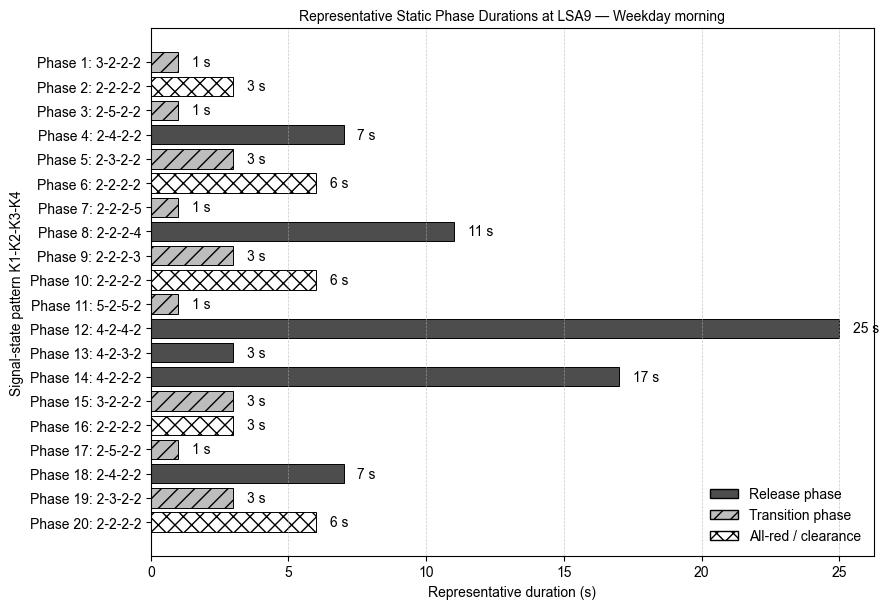

Saved SUMO TLS XML:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA9_saturation\static_tls_programs\LSA9_static_tls_weekday_morning.add.xml
SUMO state string length: 22
Approximate static cycle length: 111 s

Processing scenario: weekday_evening


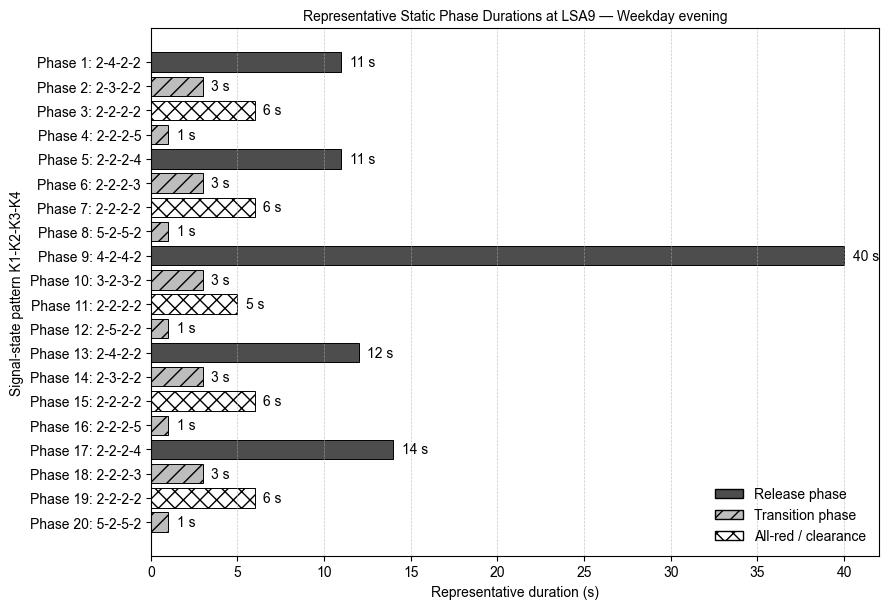

Saved SUMO TLS XML:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA9_saturation\static_tls_programs\LSA9_static_tls_weekday_evening.add.xml
SUMO state string length: 22
Approximate static cycle length: 137 s

Processing scenario: weekend_morning


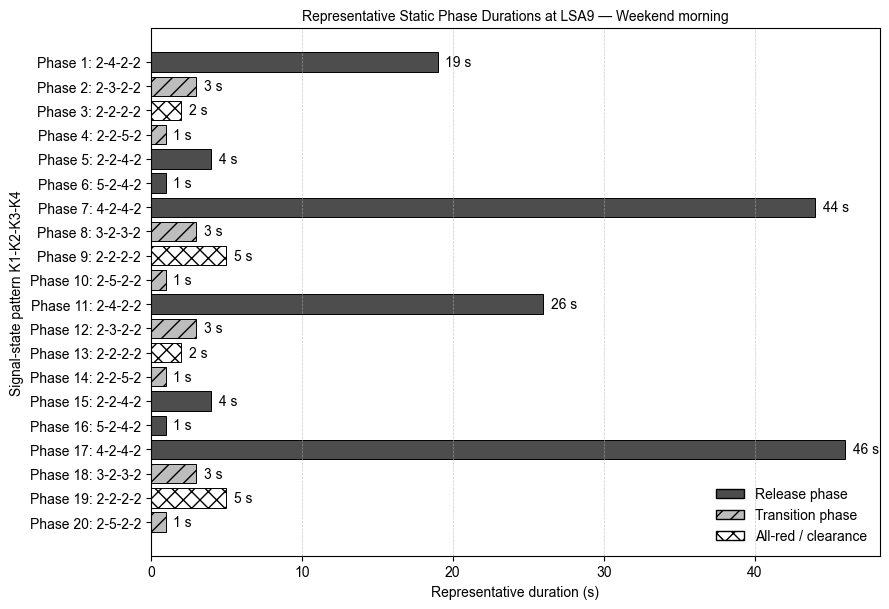

Saved SUMO TLS XML:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA9_saturation\static_tls_programs\LSA9_static_tls_weekend_morning.add.xml
SUMO state string length: 22
Approximate static cycle length: 175 s

Processing scenario: weekend_evening


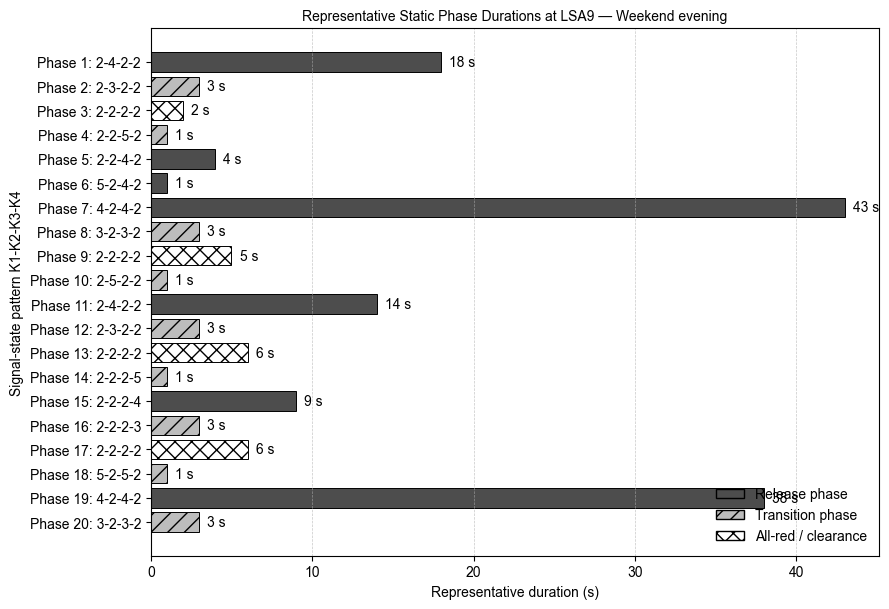

Saved SUMO TLS XML:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA9_saturation\static_tls_programs\LSA9_static_tls_weekend_evening.add.xml
SUMO state string length: 22
Approximate static cycle length: 165 s

DONE
Saved combined Excel:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA9_saturation\LSA9_all_scenarios_phase_patterns_and_static_tls.xlsx

Cycle lengths by scenario:
          scenario  approx_static_cycle_length_s
0  weekday_evening                           137
1  weekday_morning                           111
2  weekend_evening                           165
3  weekend_morning                           175


In [4]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from xml.dom import minidom

# ============================================================
# CODE 7: LSA9 STATIC TLS PROGRAMS + PHASE GRAPHS FOR ALL SCENARIOS
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

SIGNAL_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\signal_states\LD-LSA9_e31ef6a7-ced8-42fe-9ac2-fef01677d7de"
)

OUT_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA9_saturation"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

TLS_DIR = OUT_DIR / "static_tls_programs"
TLS_DIR.mkdir(parents=True, exist_ok=True)

TLS_ID = "tls_9873"

SCENARIOS = {
    "weekday_morning": {"date": "2026-03-10", "start": "08:00:00", "end": "09:00:00", "label": "Weekday morning"},
    "weekday_evening": {"date": "2026-03-23", "start": "16:00:00", "end": "17:00:00", "label": "Weekday evening"},
    "weekend_morning": {"date": "2026-03-14", "start": "08:00:00", "end": "09:00:00", "label": "Weekend morning"},
    "weekend_evening": {"date": "2026-03-22", "start": "16:00:00", "end": "17:00:00", "label": "Weekend evening"},
}

SIGNAL_GROUPS = {
    "K1": 1,
    "K2": 2,
    "K3": 3,
    "K4": 4,
}

GROUP_COLUMNS = ["K1", "K2", "K3", "K4"]

LINK_INDEX_TO_GROUP = {
    0: "K2",
    1: "K2",
    2: "K2",
    3: "K2",
    4: "K2",
    5: "K3",
    6: "K3",
    7: "K3",
    8: "K3",
    9: "K4",
    10: "K4",
    11: "K4",
    12: "K4",
    13: "K1",
    14: "K1",
    15: "K1",
    16: "K1",
    17: "K1",
    18: "K2",
    19: "K2",
    20: "K2",
    21: "K2",
}

STYLE = {
    "Release": {"color": "#4D4D4D", "hatch": "", "label": "Release phase"},
    "Transition": {"color": "#BDBDBD", "hatch": "//", "label": "Transition phase"},
    "Clearance": {"color": "#FFFFFF", "hatch": "xx", "label": "All-red / clearance"},
}

def sgstate_to_sumo_char(sg_state):
    if sg_state == 4:
        return "G"
    elif sg_state in [3, 5]:
        return "y"
    elif sg_state == 2:
        return "r"
    else:
        return "r"

def pattern_to_sumo_state(pattern):
    k1, k2, k3, k4 = [int(x) for x in pattern.split("-")]

    group_state = {
        "K1": sgstate_to_sumo_char(k1),
        "K2": sgstate_to_sumo_char(k2),
        "K3": sgstate_to_sumo_char(k3),
        "K4": sgstate_to_sumo_char(k4),
    }

    return "".join(
        group_state[LINK_INDEX_TO_GROUP[idx]]
        for idx in sorted(LINK_INDEX_TO_GROUP.keys())
    )

def classify_phase_type(pattern):
    values = [int(x) for x in pattern.split("-")]

    if all(v == 2 for v in values):
        return "Clearance"

    if any(v == 4 for v in values):
        return "Release"

    return "Transition"

def save_sumo_tls_xml(phase_table, out_xml, program_id):
    additional = ET.Element("additional")

    tl_logic = ET.SubElement(
        additional,
        "tlLogic",
        {
            "id": TLS_ID,
            "type": "static",
            "programID": program_id,
            "offset": "0",
        }
    )

    for _, row in phase_table.iterrows():
        ET.SubElement(
            tl_logic,
            "phase",
            {
                "duration": str(int(row["duration_s"])),
                "state": row["sumo_state"],
            }
        )

    rough_string = ET.tostring(additional, encoding="utf-8")
    parsed = minidom.parseString(rough_string)
    pretty_xml = parsed.toprettyxml(indent="    ")

    with open(out_xml, "w", encoding="utf-8") as f:
        f.write(pretty_xml)

def plot_phase_durations(phase_table, scenario_name, scenario_label):
    out_png = FIG_DIR / f"LSA9_representative_phase_durations_{scenario_name}.png"
    out_svg = FIG_DIR / f"LSA9_representative_phase_durations_{scenario_name}.svg"

    fig, ax = plt.subplots(figsize=(9.0, 6.2))

    y_labels = [
        f"Phase {row.phase}: {row.pattern}"
        for _, row in phase_table.iterrows()
    ]

    for i, row in phase_table.iterrows():
        style = STYLE[row["phase_type"]]

        ax.barh(
            y_labels[i],
            row["duration_s"],
            color=style["color"],
            edgecolor="black",
            linewidth=0.7,
            hatch=style["hatch"]
        )

        ax.text(row["duration_s"] + 0.5, i, f"{int(row['duration_s'])} s", va="center")

    ax.set_title(f"Representative Static Phase Durations at LSA9 — {scenario_label}")
    ax.set_xlabel("Representative duration (s)")
    ax.set_ylabel("Signal-state pattern K1-K2-K3-K4")
    ax.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.7)
    ax.invert_yaxis()

    legend_handles = []
    legend_labels = []

    for _, style in STYLE.items():
        handle = plt.Rectangle(
            (0, 0),
            1,
            1,
            facecolor=style["color"],
            edgecolor="black",
            hatch=style["hatch"]
        )
        legend_handles.append(handle)
        legend_labels.append(style["label"])

    ax.legend(legend_handles, legend_labels, frameon=False, loc="lower right")

    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.savefig(out_svg, bbox_inches="tight")
    plt.show()

rows = []

json_files = sorted(SIGNAL_DIR.glob("*.json"))
print(f"Found signal JSON files: {len(json_files)}")

for json_path in json_files:
    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        start_utc = pd.to_datetime(data["start"])

        for value in data.get("values", []):
            timestamp_utc = start_utc + pd.to_timedelta(value.get("offset", 0), unit="ms")
            timestamp_local = timestamp_utc.tz_convert("Europe/Berlin")

            sig_states = {item["id"]: item["sgState"] for item in value.get("sigState", [])}
            node_info = value.get("nodes", [{}])[0]

            row = {
                "timestamp_local": timestamp_local,
                "date": str(timestamp_local.date()),
                "time": timestamp_local.time(),
                "program": node_info.get("program"),
                "stage": node_info.get("stage"),
                "cycCnt": node_info.get("cycCnt"),
                "stgCnt": node_info.get("stgCnt"),
                "stgTran": node_info.get("stgTran"),
            }

            for group_name, signal_id in SIGNAL_GROUPS.items():
                row[group_name] = sig_states.get(signal_id)

            rows.append(row)

    except Exception as e:
        print(f"Could not parse {json_path.name}: {e}")

df_all = pd.DataFrame(rows)

if df_all.empty:
    raise ValueError("No signal data parsed.")

print("Parsed rows:", len(df_all))

all_phase_blocks = []
all_pattern_summaries = []
all_static_phase_tables = []

for scenario_name, scenario in SCENARIOS.items():
    print("\n" + "=" * 70)
    print(f"Processing scenario: {scenario_name}")
    print("=" * 70)

    start_t = pd.to_datetime(scenario["start"]).time()
    end_t = pd.to_datetime(scenario["end"]).time()

    df = df_all[
        (df_all["date"] == scenario["date"]) &
        (df_all["time"] >= start_t) &
        (df_all["time"] < end_t)
    ].copy()

    if df.empty:
        print(f"No data found for {scenario_name}. Skipping.")
        continue

    df = df.sort_values("timestamp_local").reset_index(drop=True)

    for col in GROUP_COLUMNS:
        if df[col].isna().any():
            raise ValueError(f"{col} has missing values. Check signal_id mapping.")
        df[col] = df[col].astype(int)

    df["pattern"] = df[GROUP_COLUMNS].astype(str).agg("-".join, axis=1)
    df["block_id"] = (df["pattern"] != df["pattern"].shift()).cumsum()

    phase_blocks = (
        df.groupby("block_id")
        .agg(
            start_time=("timestamp_local", "first"),
            end_time=("timestamp_local", "last"),
            date=("date", "first"),
            K1=("K1", "first"),
            K2=("K2", "first"),
            K3=("K3", "first"),
            K4=("K4", "first"),
            pattern=("pattern", "first"),
            stage=("stage", "first"),
            program=("program", "first"),
            n_seconds=("pattern", "count"),
        )
        .reset_index()
    )

    phase_blocks["duration_s"] = phase_blocks["n_seconds"]
    phase_blocks["scenario"] = scenario_name
    phase_blocks["window_start"] = scenario["start"]
    phase_blocks["window_end"] = scenario["end"]

    pattern_summary = (
        phase_blocks
        .groupby(["scenario", "pattern"] + GROUP_COLUMNS)
        .agg(
            occurrences=("block_id", "count"),
            total_duration_s=("duration_s", "sum"),
            mean_duration_s=("duration_s", "mean"),
            median_duration_s=("duration_s", "median"),
            min_duration_s=("duration_s", "min"),
            max_duration_s=("duration_s", "max"),
        )
        .reset_index()
        .sort_values("total_duration_s", ascending=False)
    )

    # First 20 compressed blocks are used as raw static approximation.
    static_phase_table = phase_blocks.head(20).copy()
    static_phase_table["phase"] = range(1, len(static_phase_table) + 1)
    static_phase_table["sumo_state"] = static_phase_table["pattern"].apply(pattern_to_sumo_state)
    static_phase_table["phase_type"] = static_phase_table["pattern"].apply(classify_phase_type)

    static_phase_table = static_phase_table[[
        "scenario",
        "phase",
        "pattern",
        "K1",
        "K2",
        "K3",
        "K4",
        "duration_s",
        "sumo_state",
        "phase_type",
    ]]

    program_id = f"derived_{scenario_name}"

    out_xml = TLS_DIR / f"LSA9_static_tls_{scenario_name}.add.xml"
    out_csv = TLS_DIR / f"LSA9_static_tls_{scenario_name}_phase_table.csv"

    save_sumo_tls_xml(static_phase_table, out_xml, program_id)
    static_phase_table.to_csv(out_csv, index=False, encoding="utf-8-sig")

    plot_phase_durations(static_phase_table, scenario_name, scenario["label"])

    print("Saved SUMO TLS XML:")
    print(out_xml)

    print("SUMO state string length:", len(static_phase_table.iloc[0]["sumo_state"]))
    print("Approximate static cycle length:", static_phase_table["duration_s"].sum(), "s")

    phase_blocks_excel = phase_blocks.copy()
    phase_blocks_excel["start_time"] = phase_blocks_excel["start_time"].astype(str)
    phase_blocks_excel["end_time"] = phase_blocks_excel["end_time"].astype(str)

    all_phase_blocks.append(phase_blocks_excel)
    all_pattern_summaries.append(pattern_summary)
    all_static_phase_tables.append(static_phase_table)

combined_phase_blocks = pd.concat(all_phase_blocks, ignore_index=True)
combined_pattern_summary = pd.concat(all_pattern_summaries, ignore_index=True)
combined_static_phase_table = pd.concat(all_static_phase_tables, ignore_index=True)

OUT_XLSX = OUT_DIR / "LSA9_all_scenarios_phase_patterns_and_static_tls.xlsx"

with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as writer:
    combined_phase_blocks.to_excel(writer, sheet_name="Phase_Blocks", index=False)
    combined_pattern_summary.to_excel(writer, sheet_name="Pattern_Summary", index=False)
    combined_static_phase_table.to_excel(writer, sheet_name="Static_TLS_Phase_Table", index=False)

print("\nDONE")
print("Saved combined Excel:")
print(OUT_XLSX)

print("\nCycle lengths by scenario:")
print(
    combined_static_phase_table
    .groupby("scenario")["duration_s"]
    .sum()
    .reset_index(name="approx_static_cycle_length_s")
)

**For LSA8, no detector count data was available. Therefore, the analysis was limited to the derivation of an approximate static signal program from the signal-state process data. The signal-state data was parsed for the available representative period and compressed into recurring phase blocks based on the signal groups K1–K6.**

**The extracted weekday morning pattern showed four main release phases. The first major release phase served signal groups K1 and K3, followed by a second release phase for K2 and K5. Two shorter release phases were also identified for K3/K4 and K1/K6. Between these release phases, short intermediate states were observed and interpreted as transition or clearance intervals.**

**For the SUMO implementation, the original release durations were preserved, while short consecutive transition states were aggregated into longer transition intervals. This simplification did not change the total cycle length. The resulting static signal program has an approximate cycle length of 103 seconds and provides a reproducible approximation of the observed signal control logic for LSA8.**

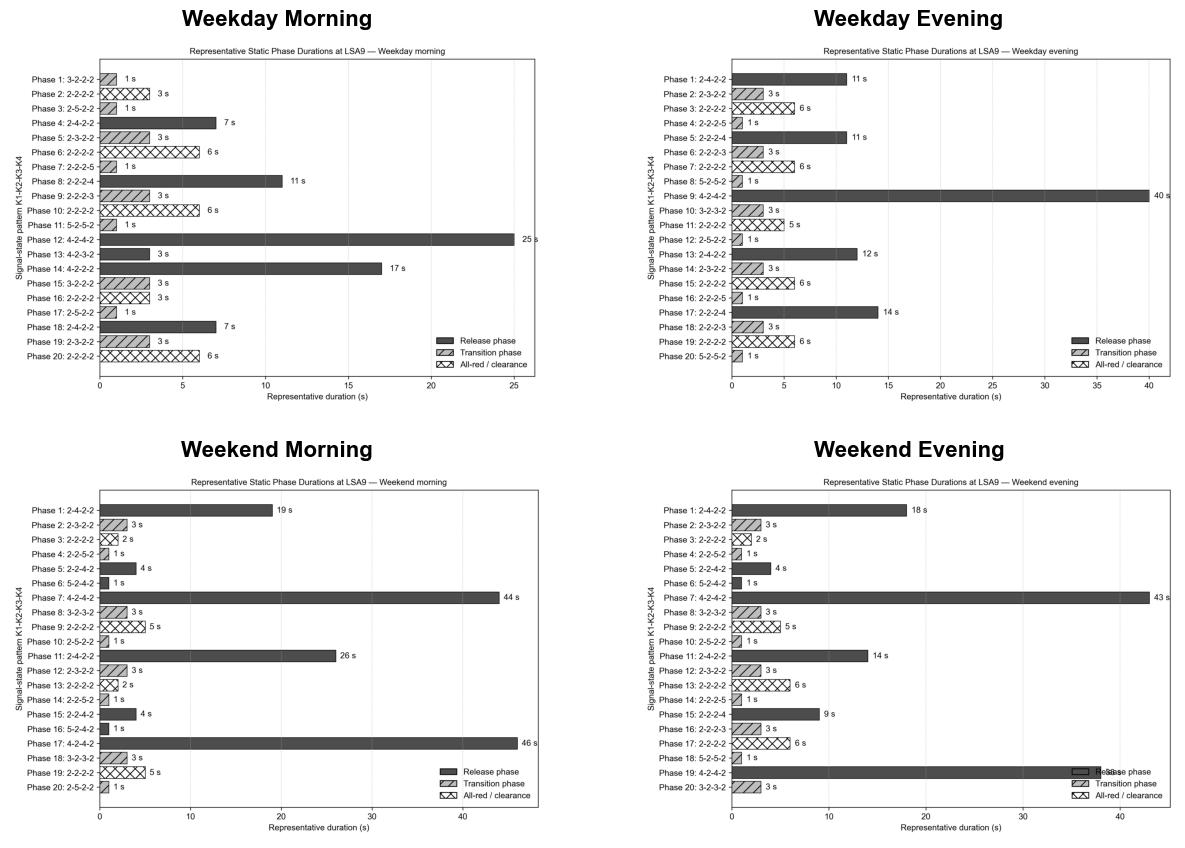

Saved: C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA9_saturation\figures\LSA9_representative_phase_durations_combined.png


In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# ============================================================
# THESIS STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

# ============================================================
# SETTINGS
# ============================================================

BASE_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA9_saturation\figures"
)

scenarios = [
    ("weekday_morning", "Weekday Morning"),
    ("weekday_evening", "Weekday Evening"),
    ("weekend_morning", "Weekend Morning"),
    ("weekend_evening", "Weekend Evening"),
]

prefix = "LSA9_representative_phase_durations"

out_file = BASE_DIR / "LSA9_representative_phase_durations_combined.png"

# ============================================================
# CREATE COMBINED FIGURE
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, (scenario, title) in zip(axes, scenarios):

    img_path = BASE_DIR / f"{prefix}_{scenario}.png"

    if not img_path.exists():
        raise FileNotFoundError(f"File not found: {img_path}")

    img = mpimg.imread(img_path)

    ax.imshow(img)
    ax.set_title(title, fontsize=16, fontweight="bold", pad=12)
    ax.axis("off")

plt.tight_layout(pad=2.0)

plt.savefig(out_file, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {out_file}")